# 🏥 Data Cleanser — Healthcare Patient Data Preprocessing

## Project Objective

This project focuses on cleaning and preprocessing a healthcare patient dataset containing:

- Missing values
- Extreme observations / outliers

The main objectives are:

1. Inspect and understand the raw dataset.
2. Identify missing values and prepare a summary report.
3. Apply multiple missing-value imputation techniques.
4. Compare the imputation methods.
5. Identify numerical variables containing potential outliers.
6. Detect and handle outliers using multiple methods.
7. Compare the outlier-treatment methods.
8. Create and validate a final cleaned dataset.

### Target Variable

`disease_risk`

- `0` → Low Risk
- `1` → High Risk

In [90]:
# ========================================
# IMPORT LIBRARIES
# =======================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer,KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from scipy.stats import zscore

print("All Libraries imported successfully!")

All Libraries imported successfully!


## 1. Load Dataset

The raw dataset intentionally contains missing values and extreme observations.

We will keep the original dataset unchanged and use copies for different cleaning methods.

In [106]:
# ======================================
# LOAD DATASET
# ======================================
df = pd.read_csv("Dataset/patient_health_records_dirty.csv")

df.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,1001,56.0,Female,South,22.7,147.2,216.1,106.6,1
1,1002,69.0,Female,East,23.1,117.6,209.2,117.9,1
2,1003,46.0,Male,East,19.7,134.9,134.0,100.0,0
3,1004,32.0,Male,West,29.6,146.5,NaN,125.4,1
4,1005,60.0,Female,West,19.2,127.4,245.5,76.9,0


In [4]:
print("Rows: ",  df.shape[0])
print("Columns: ", df.shape[1])
print("Shape: ", df.shape)

Rows:  500
Columns:  9
Shape:  (500, 9)


## 2. Dataset Overview

The dataset contains patient-level healthcare information.

Before cleaning, we inspect its structure, data types, statistical summary, duplicate records, and missing values.

In [5]:
df.columns

Index(['patient_id', 'age', 'gender', 'region', 'bmi', 'blood_pressure',
       'cholesterol', 'glucose', 'disease_risk'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      500 non-null    int64  
 1   age             480 non-null    float64
 2   gender          480 non-null    object 
 3   region          480 non-null    object 
 4   bmi             480 non-null    float64
 5   blood_pressure  500 non-null    float64
 6   cholesterol     480 non-null    float64
 7   glucose         480 non-null    float64
 8   disease_risk    500 non-null    int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 35.3+ KB


In [7]:
df.describe()

,patient_id,age,bmi,blood_pressure,cholesterol,glucose,disease_risk
count,500.000000,480.000000,480.000000,500.000000,480.000000,480.000000,500.000000
mean,1250.500000,50.185417,25.291042,126.450000,203.004792,103.112708,0.434000
std,144.481833,18.567627,4.793531,19.975531,37.203938,27.456842,0.496121
min,1001.000000,18.000000,8.900000,85.000000,55.000000,35.000000,0.000000
25%,1125.750000,35.000000,22.375000,116.075000,179.175000,87.900000,0.000000
50%,1250.500000,50.000000,25.150000,125.400000,202.350000,102.400000,0.000000
75%,1375.250000,66.000000,28.100000,134.500000,223.500000,115.725000,1.000000
max,1500.000000,80.000000,52.000000,280.000000,450.000000,350.000000,1.000000


In [9]:
df.dtypes

patient_id          int64
age               float64
gender             object
region             object
bmi               float64
blood_pressure    float64
cholesterol       float64
glucose           float64
disease_risk        int64
dtype: object

In [10]:
print("Duplicate rows: ", df.duplicated().sum())

print("Duplicate patient IDs: ",df["patient_id"].duplicated().sum())

Duplicate rows:  0
Duplicate patient IDs:  0


# Part A — Missing Value Analysis

Missing values can affect statistical analysis and machine-learning models.

First, we identify the number and percentage of missing observations in every column.

In [11]:
# ============================================
# MISSING VALUE REPORT
# ============================================

missing_count = df.isnull().sum()
missing_percentage = (df.isnull().mean() * 100)

missing_report = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

display(missing_report)

,Missing Count,Missing Percentage
patient_id,0,0.0
age,20,4.0
gender,20,4.0
region,20,4.0
bmi,20,4.0
blood_pressure,0,0.0
cholesterol,20,4.0
glucose,20,4.0
disease_risk,0,0.0


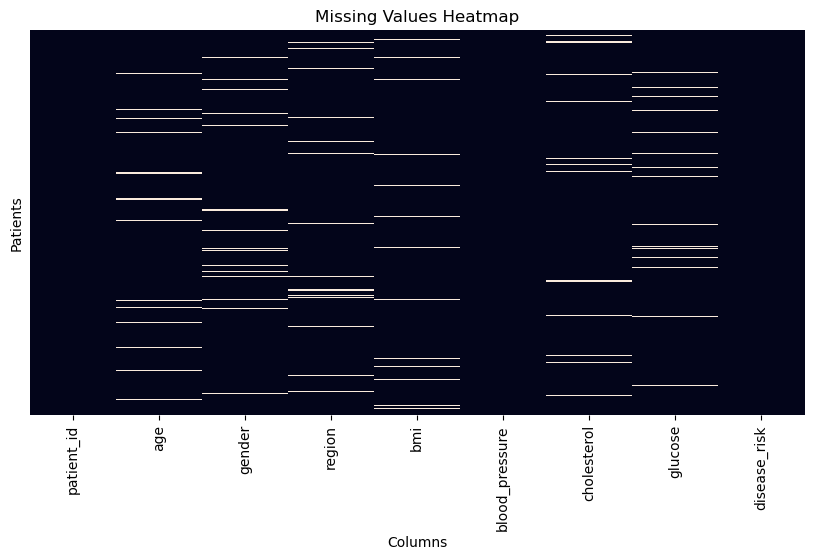

In [12]:
# Missing Value Heatmap

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(),cbar=False,yticklabels=False)
plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Patients")
plt.show()

In [13]:
# ============================================
# COLUMN GROUPS
# ============================================

numerical_columns = [
    "age",
    "bmi",
    "blood_pressure",
    "cholesterol",
    "glucose"
]

categorical_columns = [
    "gender",
    "region"
]

target_column = "disease_risk"

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical_columns:")
print(categorical_columns)

print("\nTarget:")
print(target_column)

Numerical columns:
['age', 'bmi', 'blood_pressure', 'cholesterol', 'glucose']

Categorical_columns:
['gender', 'region']

Target:
disease_risk


## A.1 Simple Imputation

For numerical variables, median imputation is used because the dataset contains extreme observations and the median is less sensitive to outliers than the mean.

For categorical variables, the most frequent category is used.

In [91]:
df_simple = df.copy()

# Numerical columns → median
numeric_imputer = SimpleImputer(strategy="median")

df_simple[numerical_columns] = numeric_imputer.fit_transform(df_simple[numerical_columns])

# Categorical columns → most frequent
categorical_imputer = SimpleImputer(strategy="most_frequent")

df_simple[categorical_columns] = categorical_imputer.fit_transform(df_simple[categorical_columns])

df_simple.isnull().sum()

patient_id        0
age               0
gender            0
region            0
bmi               0
blood_pressure    0
cholesterol       0
glucose           0
disease_risk      0
dtype: int64

## A.2 Most Frequent Imputation

Most Frequent Imputation replaces missing categorical values with the category that occurs most often.

This method is appropriate for categorical variables such as `gender` and `region`.

In [92]:
df_most_frequent = df.copy()

most_frequent_imputer = SimpleImputer(
    strategy="most_frequent"
)

df_most_frequent[categorical_columns] = (
    most_frequent_imputer.fit_transform(
        df_most_frequent[categorical_columns]
    )
)

# Numerical values are filled with median
df_most_frequent[numerical_columns] = (
    SimpleImputer(
        strategy="median"
    ).fit_transform(
        df_most_frequent[numerical_columns]
    )
)

df_most_frequent.isnull().sum()

patient_id        0
age               0
gender            0
region            0
bmi               0
blood_pressure    0
cholesterol       0
glucose           0
disease_risk      0
dtype: int64

## A.3 Missing Indicator + Random Sample Imputation

A missing indicator records whether a value was originally missing.

- `0` → value was originally present
- `1` → value was originally missing

The missing value is then replaced by a randomly selected observed value from the same column.

In [93]:
df_random = df.copy()

for column in numerical_columns+categorical_columns:
    df_random[column + "_missing"] =  df_random[column].isnull().astype(int)

df_random.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk,age_missing,bmi_missing,blood_pressure_missing,cholesterol_missing,glucose_missing,gender_missing,region_missing
0,1001,56.0,Female,South,22.7,147.2,216.1,106.6,1,0,0,0,0,0,0,0
1,1002,69.0,Female,East,23.1,117.6,209.2,117.9,1,0,0,0,0,0,0,0
2,1003,46.0,Male,East,19.7,134.9,134.0,100.0,0,0,0,0,0,0,0,0
3,1004,32.0,Male,West,29.6,146.5,NaN,125.4,1,0,0,0,1,0,0,0
4,1005,60.0,Female,West,19.2,127.4,245.5,76.9,0,0,0,0,0,0,0,0


In [108]:
# Random Sample Imputation
np.random.seed(42)

for column in numerical_columns+categorical_columns:
    missing_mask = df_random[column].isnull()
    observed_values = df_random.loc[
        ~missing_mask,
        column
    ].dropna()

    random_values = np.random.choice(
        observed_values,
        size=missing_mask.sum(),
        replace = True
    )

    df_random.loc[
        missing_mask,
        column
    ] = random_values

df_random.isnull().sum()

patient_id                0
age                       0
gender                    0
region                    0
bmi                       0
blood_pressure            0
cholesterol               0
glucose                   0
disease_risk              0
age_missing               0
bmi_missing               0
blood_pressure_missing    0
cholesterol_missing       0
glucose_missing           0
gender_missing            0
region_missing            0
dtype: int64

## A.4 KNN Imputation

KNN Imputation estimates missing numerical values using similar observations.

The project requires experimenting with different values of `k`.

The primary KNN model will use:

`n_neighbors = 3`

In [94]:
df_knn = df.copy()

knn_imputer = KNNImputer(n_neighbors=3)

df_knn[numerical_columns] = knn_imputer.fit_transform(df_knn[numerical_columns])

df_knn[categorical_columns] = (
    SimpleImputer(
        strategy="most_frequent"
    )
    .fit_transform(
        df_knn[categorical_columns]
    )
)

df_knn.isnull().sum()

patient_id        0
age               0
gender            0
region            0
bmi               0
blood_pressure    0
cholesterol       0
glucose           0
disease_risk      0
dtype: int64

## A.5 MICE-Style Iterative Imputation

MICE stands for Multiple Imputation by Chained Equations.

It estimates missing numerical values iteratively by using relationships between variables.

In Python, `IterativeImputer` is used to implement a MICE-style iterative imputation approach.

In [96]:
df_mice = df.copy()

mice_imputer = IterativeImputer(max_iter=10,random_state=42)

df_mice[numerical_columns] = mice_imputer.fit_transform(df_mice[numerical_columns])

df_mice[categorical_columns]=(
    SimpleImputer(
        strategy="most_frequent"
    )
    .fit_transform(df_mice[categorical_columns]))

df_mice.isnull().sum()

patient_id        0
age               0
gender            0
region            0
bmi               0
blood_pressure    0
cholesterol       0
glucose           0
disease_risk      0
dtype: int64

In [109]:
# Compare All Imputation Methods

comparison_missing = pd.DataFrame({
    "Original": df.isnull().sum(),
    "Simple Imputer": df_simple.isnull().sum(),
    "Random Sample": df_random.isnull().sum(),
    "KNN": df_knn.isnull().sum(),
    "MICE": df_mice.isnull().sum()
})

display(comparison_missing)


,Original,Simple Imputer,Random Sample,KNN,MICE
age,20.0,0.0,0,0.0,0.0
age_missing,NaN,NaN,0,NaN,NaN
blood_pressure,0.0,0.0,0,0.0,0.0
blood_pressure_missing,NaN,NaN,0,NaN,NaN
bmi,20.0,0.0,0,0.0,0.0
bmi_missing,NaN,NaN,0,NaN,NaN
cholesterol,20.0,0.0,0,0.0,0.0
cholesterol_missing,NaN,NaN,0,NaN,NaN
disease_risk,0.0,0.0,0,0.0,0.0
gender,20.0,0.0,0,0.0,0.0


In [110]:
# Compare Imputed BMI

comparison_bmi = pd.DataFrame({
    "Original": df["bmi"],
    "Simple_Imputer": df_simple["bmi"],
    "Random_Sample": df_random["bmi"],
    "KNN": df_knn["bmi"],
    "MICE": df_mice["bmi"]
})

display(comparison_bmi.head(20))

,Original,Simple_Imputer,Random_Sample,KNN,MICE
0,22.7,22.70,22.7,22.700000,22.700000
1,23.1,23.10,23.1,23.100000,23.100000
2,19.7,19.70,19.7,19.700000,19.700000
3,29.6,29.60,29.6,29.600000,29.600000
4,19.2,19.20,19.2,19.200000,19.200000
5,32.9,32.90,32.9,32.900000,32.900000
6,32.9,32.90,32.9,32.900000,32.900000
7,23.5,23.50,23.5,23.500000,23.500000
8,26.3,26.30,26.3,26.300000,26.300000
9,24.7,24.70,24.7,24.700000,24.700000


# Part B — Outlier Detection and Treatment

Outliers are observations that are unusually far from the typical range of a variable.

Before selecting outlier columns, all relevant numerical measurement variables are examined.

The following methods will be compared:

1. Z-Score
2. IQR
3. Percentile
4. Winsorization

In [28]:
# Use KNN-imputed dataset for outlier analysis
df_clean_missing = df_knn.copy()

df_clean_missing.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,1001,56.0,Female,South,22.7,147.2,216.1,106.6,1
1,1002,69.0,Female,East,23.1,117.6,209.2,117.9,1
2,1003,46.0,Male,East,19.7,134.9,134.0,100.0,0
3,1004,32.0,Male,West,29.6,146.5,209.1,125.4,1
4,1005,60.0,Female,West,19.2,127.4,245.5,76.9,0


In [101]:
numeric_columns = df_clean_missing.select_dtypes(
    include=np.number
).columns.difference(
    ["patient_id", "disease_risk"]
)
print("Numerical measurement columns:")
print(numeric_columns)

Numerical measurement columns:
Index(['age', 'blood_pressure', 'bmi', 'cholesterol', 'glucose'], dtype='object')


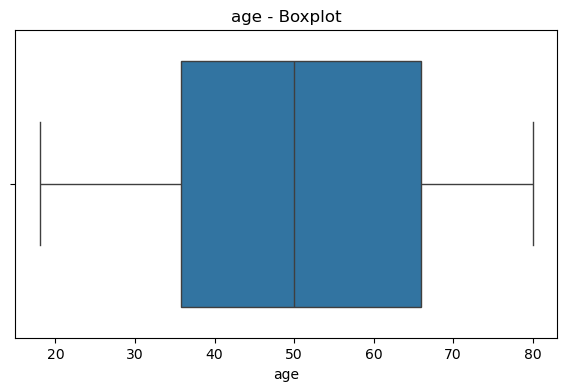

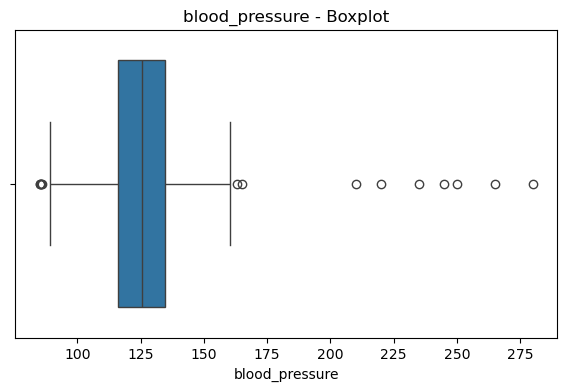

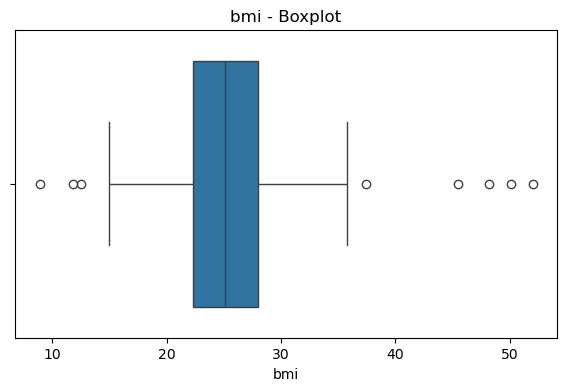

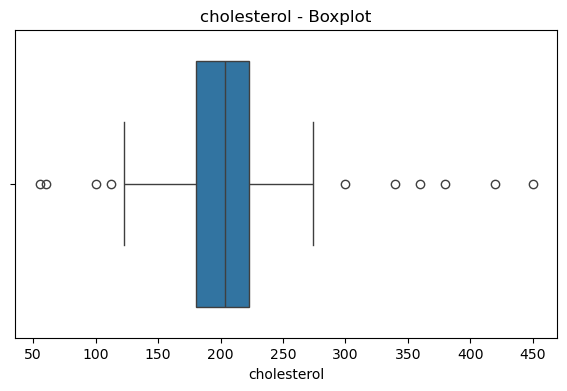

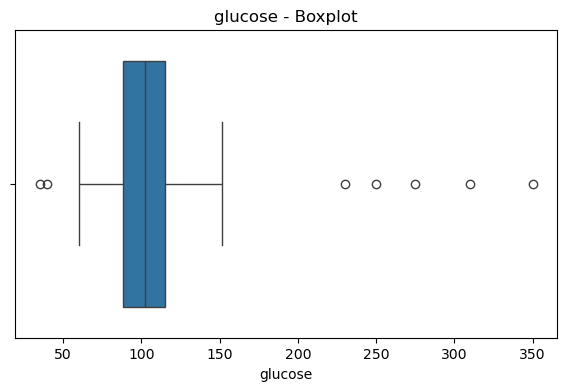

In [37]:
# Compare ALL Numerical Columns

for column in numeric_columns:
    plt.figure(figsize = (7,4))
    sns.boxplot(
        x=df_clean_missing[column]
    )
    plt.title(f"{column} - Boxplot")
    plt.xlabel(column)
    plt.show()

In [102]:
# Select Outlier Columns
outlier_columns = ["bmi","blood_pressure","cholesterol","glucose"]
outlier_columns

['bmi', 'blood_pressure', 'cholesterol', 'glucose']

## B.1 Z-Score Method

The Z-score measures how far an observation is from the mean in terms of standard deviations.

For this project:

`|Z| > 3`

is treated as an extreme outlier.

The analysis is first performed across all numerical measurement columns.

In [41]:
# Z-score Analysis
df_zscore = df_clean_missing.copy()

zscores = np.abs(
    zscore(df_zscore[outlier_columns]))

z_outlier_mask = (zscores > 3).any(axis=1)

print("Z-score outliers:",z_outlier_mask.sum())

Z-score outliers: 24


In [43]:
# Z-score Removal

df_zscore_clean = df_zscore[
    ~z_outlier_mask
].copy()

print("Before: ", df_zscore.shape)
print("After: ", df_zscore_clean.shape)

Before:  (500, 9)
After:  (476, 9)


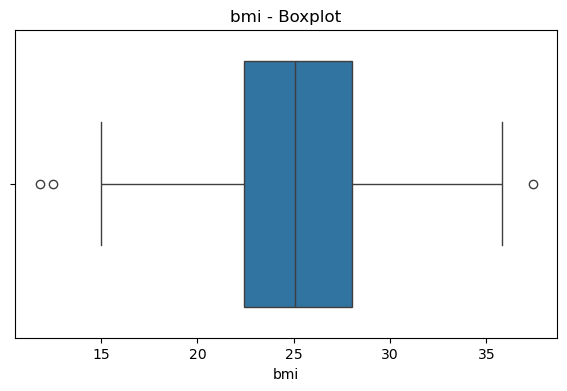

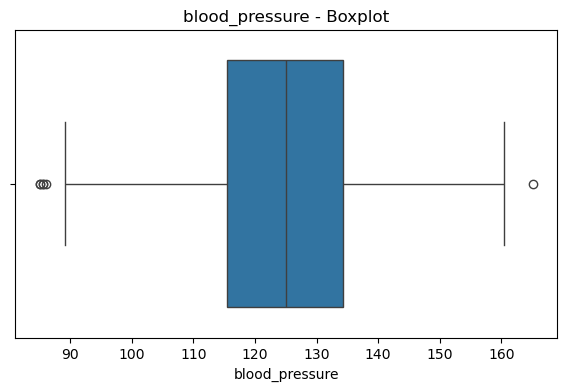

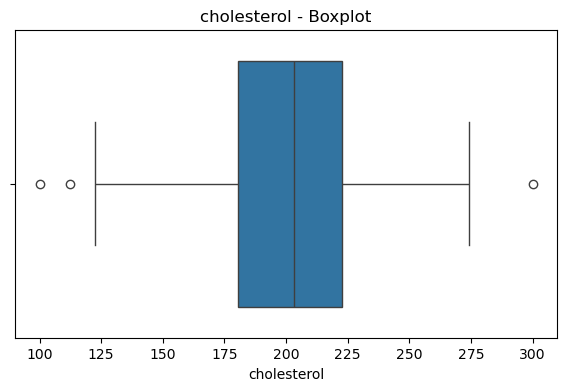

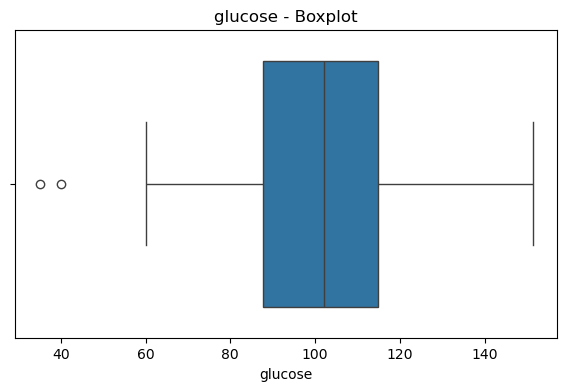

In [44]:
for column in outlier_columns:
    plt.figure(figsize = (7,4))
    sns.boxplot(
        x=df_zscore_clean[column]
    )
    plt.title(f"{column} - Boxplot")
    plt.xlabel(column)
    plt.show()

## B.2 IQR Method

The Interquartile Range measures the spread of the middle 50% of the data.

IQR = Q3 − Q1

Lower Bound = Q1 − 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

Values outside these bounds are treated as outliers.

In [50]:
# IQR

df_IQR = df_clean_missing.copy()

iqr_outlier_mask = pd.Series(
    False,
    index=df_IQR.index
)

for column in outlier_columns:

    Q1 = df_IQR[column].quantile(0.25)
    Q3 = df_IQR[column].quantile(0.75)

    IQR = Q3 -  Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    column_mask = (
        (df_IQR[column] < lower_bound) |
        (df_IQR[column] > upper_bound)
    )

    iqr_outlier_mask = (iqr_outlier_mask | column_mask)

    print(f"\n{column}")
    print("Q1: ", Q1)
    print("Q3: ", Q3)
    print("IQR: ", IQR)
    print("Lower Bound: ", lower_bound)
    print("Upper Bound: ", upper_bound)


bmi
Q1:  22.349999999999998
Q3:  28.025
IQR:  5.675000000000001
Lower Bound:  13.837499999999997
Upper Bound:  36.5375

blood_pressure
Q1:  116.07499999999999
Q3:  134.5
IQR:  18.42500000000001
Lower Bound:  88.43749999999997
Upper Bound:  162.13750000000002

cholesterol
Q1:  180.22500000000002
Q3:  223.125
IQR:  42.89999999999998
Lower Bound:  115.87500000000006
Upper Bound:  287.47499999999997

glucose
Q1:  88.125
Q3:  115.125
IQR:  27.0
Lower Bound:  47.625
Upper Bound:  155.625


In [51]:
# Remove IQR Outliers

df_iqr_clean = df_IQR[
    ~iqr_outlier_mask
].copy()

print("Before: ", df_IQR.shape)
print("After: ", df_iqr_clean.shape)

print("Total IQR outliers: ", iqr_outlier_mask.sum())

Before:  (500, 9)
After:  (462, 9)
Total IQR outliers:  38


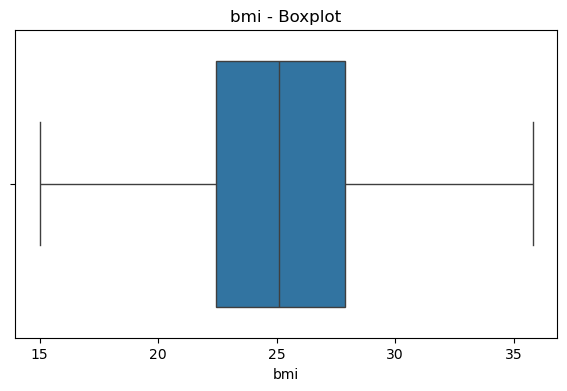

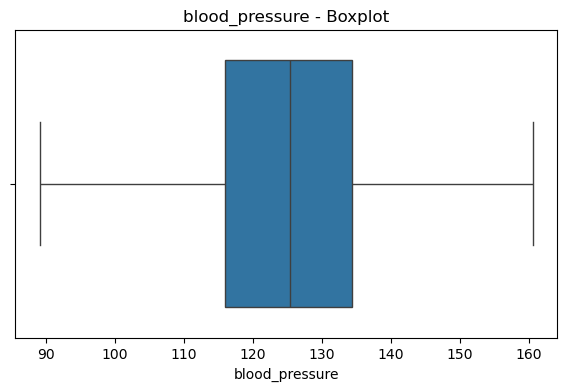

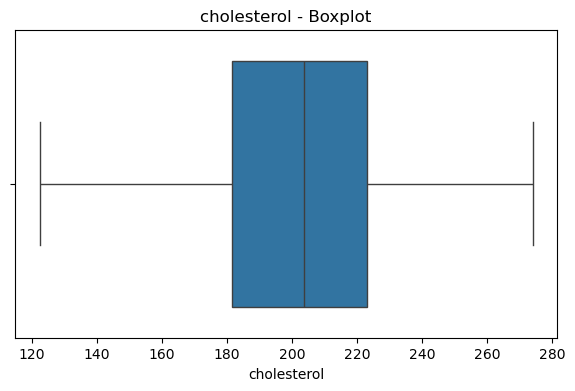

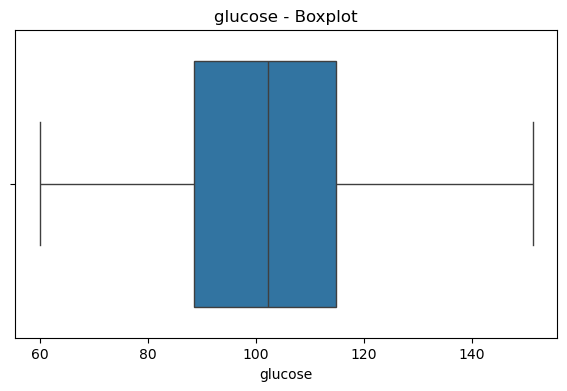

In [52]:
for column in outlier_columns:
    plt.figure(figsize = (7,4))
    sns.boxplot(
        x=df_iqr_clean[column]
    )
    plt.title(f"{column} - Boxplot")
    plt.xlabel(column)
    plt.show()

## B.3 Percentile Method

The 5st and 95th percentiles are used as the lower and upper limits.

Values below the 5st percentile or above the 95th percentile are treated as extreme observations.

For comparison with the other removal methods, these rows are removed.

In [65]:
# Percentile
df_percentile = df_clean_missing.copy()

precentile_outlier_mask = pd.Series(
    False,
    index= df_percentile.index
)

for column in outlier_columns:

    lower = df_percentile[column].quantile(0.05)
    upper = df_percentile[column].quantile(0.95)

    column_mask = (
        (df_percentile[column] < lower ) |
        (df_percentile[column] > upper ) 
    )

    precentile_outlier_mask = (precentile_outlier_mask | column_mask )

    print(f"{column}")
    print("5th percentile: ",lower)
    print("95th percentile: ",upper)

bmi
5th percentile:  18.5
95th percentile:  32.205
blood_pressure
5th percentile:  101.57499999999999
95th percentile:  150.3
cholesterol
5th percentile:  155.25
95th percentile:  251.85499999999996
glucose
5th percentile:  66.985
95th percentile:  132.605


In [112]:
# Remove Percentile Outliers
df_percentile_clean = df_percentile[
    ~precentile_outlier_mask
].copy()

print("Before: ", df_percentile.shape)
print("After: ", df_percentile_clean.shape)
print("Total Percentile outliers: ", precentile_outlier_mask.sum())

Before:  (500, 9)
After:  (328, 9)
Total Percentile outliers:  172


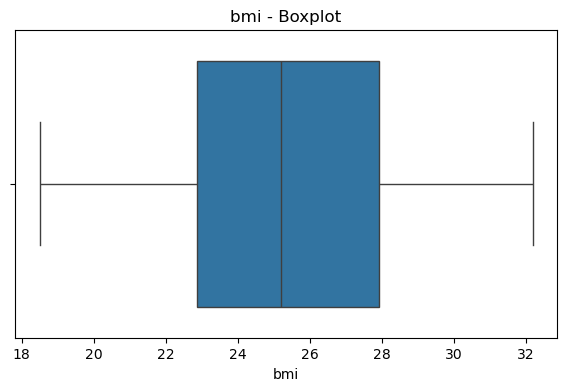

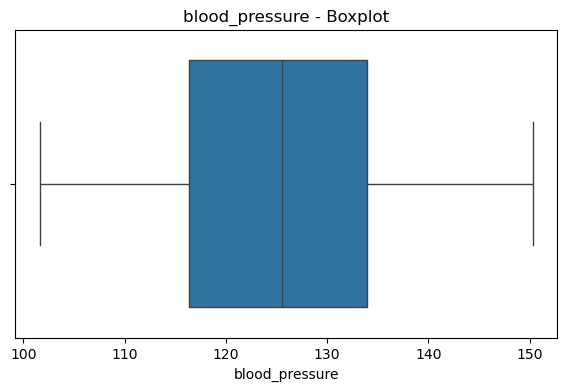

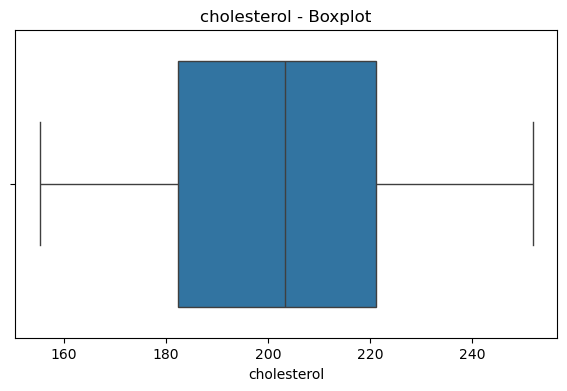

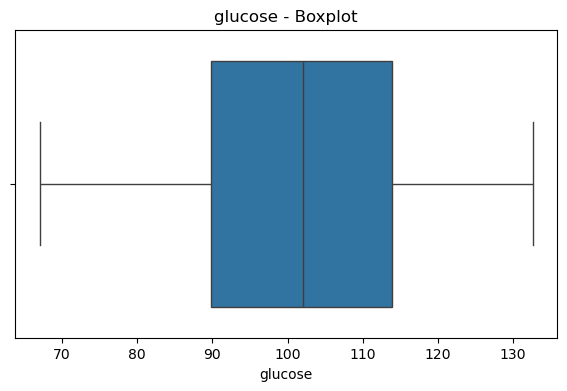

In [67]:
for column in outlier_columns:
    plt.figure(figsize = (7,4))
    sns.boxplot(
        x=df_percentile_clean[column]
    )
    plt.title(f"{column} - Boxplot")
    plt.xlabel(column)
    plt.show()

## B.4 Winsorization

Winsorization does not remove rows.

Instead, extreme values are capped at predefined percentile limits.

In this project:

- Values below the 5st percentile are replaced by the 5st percentile.
- Values above the 95th percentile are replaced by the 95th percentile.

This preserves all patient records while reducing the influence of extreme observations.

In [63]:
df_winsor = df_clean_missing.copy()

winsor_limits = {}

for column in outlier_columns:
    lower = df_winsor[column].quantile(0.05)
    upper = df_winsor[column].quantile(0.95)

    winsor_limits[column] = {"lower": lower,"upper": upper}

    df_winsor[column] = (df_winsor[column].clip(lower=lower,upper=upper))

print("Winsorization completed")


Winsorization completed


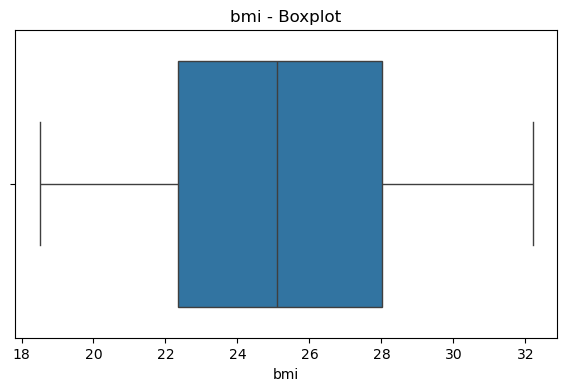

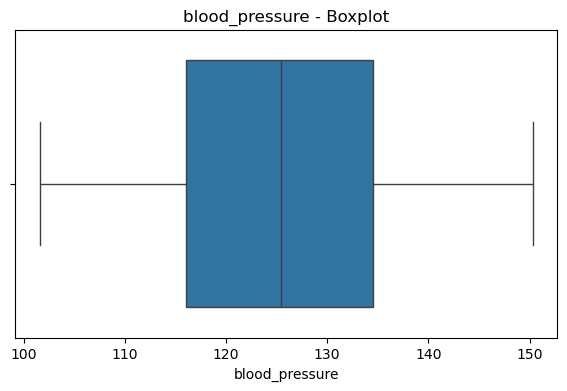

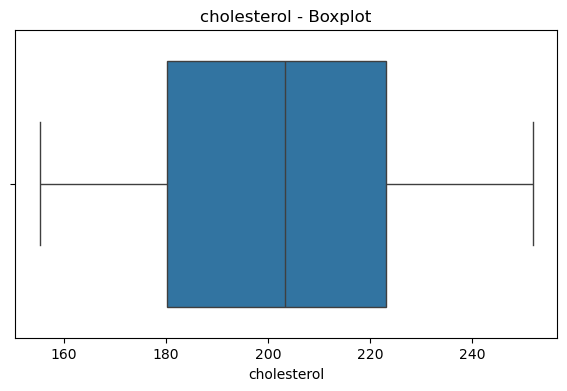

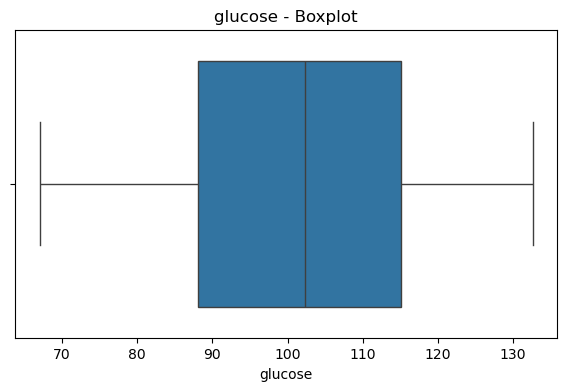

In [64]:
for column in outlier_columns:
    plt.figure(figsize = (7,4))
    sns.boxplot(
        x=df_winsor[column]
    )
    plt.title(f"{column} - Boxplot")
    plt.xlabel(column)
    plt.show()

In [103]:
# Compare Outlier Methods

outlier_comparison = pd.DataFrame({
    "Method": [
        "Original",
        "Z-Score",
        "IQR",
        "Percentile",
        "Winsorization"
    ],

    "Rows": [
        df_clean_missing.shape[0],
        df_zscore_clean.shape[0],
        df_iqr_clean.shape[0],
        df_percentile_clean.shape[0],
        df_winsor.shape[0]
    ],

    "Rows Removed": [
        0,
        df_clean_missing.shape[0] -
        df_zscore_clean.shape[0],

        df_clean_missing.shape[0] -
        df_iqr_clean.shape[0],

        df_clean_missing.shape[0] -
        df_percentile_clean.shape[0],

        0
    ]
})

display(outlier_comparison)

,Method,Rows,Rows Removed
0,Original,500,0
1,Z-Score,476,24
2,IQR,462,38
3,Percentile,328,172
4,Winsorization,500,0


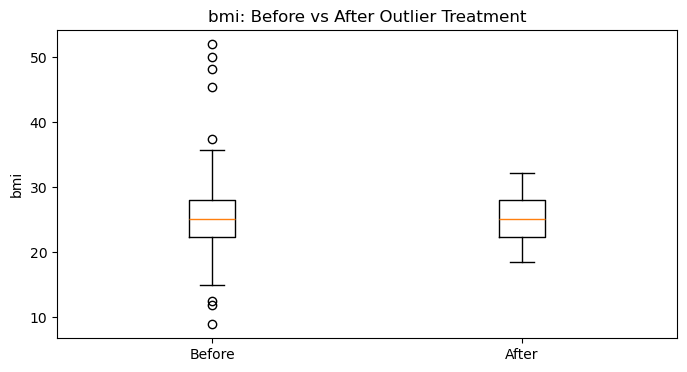

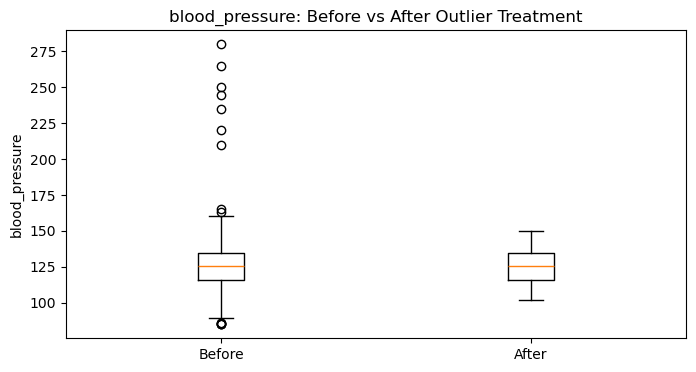

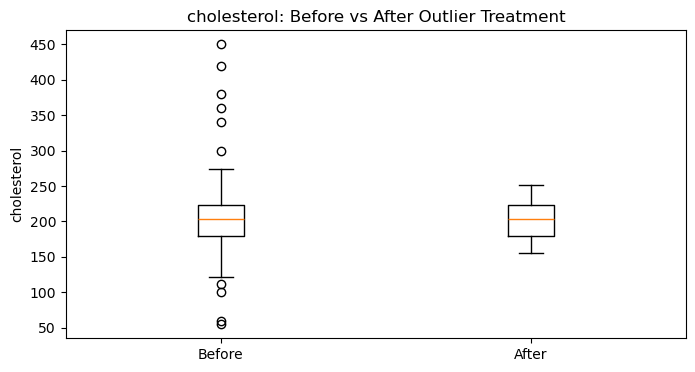

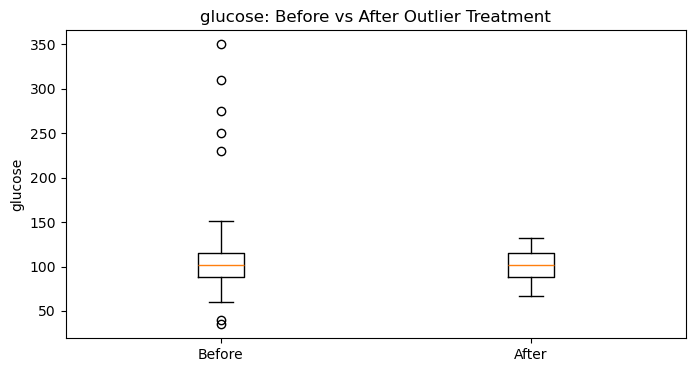

In [75]:
# Before vs After Winsorization

for column in outlier_columns:

    plt.figure(figsize=(8, 4))

    plt.boxplot(
        [
            df_clean_missing[column],
            df_winsor[column]
        ],
        tick_labels=["Before", "After"]
    )

    plt.title(
        f"{column}: Before vs After Outlier Treatment"
    )

    plt.ylabel(column)

    plt.show()

In [72]:
# Summary Statistics Comparison
summary_before = df_clean_missing[outlier_columns].describe().T
summary_after = df_winsor[outlier_columns].describe().T

print("====== BEFORE OUTLIER TREATMENT ======")
print(summary_before)

print("====== AFTER WINSORIZATION ======")
print(summary_after)


====== BEFORE OUTLIER TREATMENT ======
                count        mean        std   min      25%         50%  \
bmi             500.0   25.255600   4.742027   8.9   22.350   25.100000   
blood_pressure  500.0  126.450000  19.975531  85.0  116.075  125.400000   
cholesterol     500.0  203.106467  36.596196  55.0  180.225  203.283333   
glucose         500.0  102.910267  27.026212  35.0   88.125  102.250000   

                    75%    max  
bmi              28.025   52.0  
blood_pressure  134.500  280.0  
cholesterol     223.125  450.0  
glucose         115.125  350.0  
====== AFTER WINSORIZATION ======
                count        mean        std      min      25%         50%  \
bmi             500.0   25.160250   3.876849   18.500   22.350   25.100000   
blood_pressure  500.0  125.287950  13.121977  101.575  116.075  125.400000   
cholesterol     500.0  202.260517  27.848036  155.250  180.225  203.283333   
glucose         500.0  101.477367  18.518188   66.985   88.125  102.250000

# Part C — Final Clean Dataset

For the final dataset:

### Missing Values

KNN Imputation is used for numerical variables because it estimates missing values using similar observations.

Categorical missing values are handled using the most frequent category.

### Outliers

Winsorization is selected because it reduces the influence of extreme observations without removing patient records.

In [79]:
# Create Final Dataset
final_df  = df_winsor.copy()

print("Final Dataset Shape:",final_df.shape)
final_df.head()

Final Dataset Shape: (500, 9)


,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,1001,56.0,Female,South,22.7,147.2,216.10,106.6,1
1,1002,69.0,Female,East,23.1,117.6,209.20,117.9,1
2,1003,46.0,Male,East,19.7,134.9,155.25,100.0,0
3,1004,32.0,Male,West,29.6,146.5,209.10,125.4,1
4,1005,60.0,Female,West,19.2,127.4,245.50,76.9,0


In [80]:
# Final Missing Check
final_df.isnull().sum()

patient_id        0
age               0
gender            0
region            0
bmi               0
blood_pressure    0
cholesterol       0
glucose           0
disease_risk      0
dtype: int64

In [82]:
# Final Duplicate Check

print("Duplicate rows:",final_df.duplicated().sum())

print("Duplicate patient IDs: ",final_df["patient_id"].duplicated().sum())

Duplicate rows: 0
Duplicate patient IDs:  0


In [83]:
# Target Variable Check
print(final_df["disease_risk"].value_counts())

print("\nTarget percentages:")

print(final_df["disease_risk"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
     )

disease_risk
0    283
1    217
Name: count, dtype: int64

Target percentages:
disease_risk
0    56.6
1    43.4
Name: proportion, dtype: float64


In [84]:
# Final Statistical Summary
final_df.describe()

,patient_id,age,bmi,blood_pressure,cholesterol,glucose,disease_risk
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,1250.500000,50.094667,25.160250,125.287950,202.260517,101.477367,0.434000
std,144.481833,18.322172,3.876849,13.121977,27.848036,18.518188,0.496121
min,1001.000000,18.000000,18.500000,101.575000,155.250000,66.985000,0.000000
25%,1125.750000,35.833333,22.350000,116.075000,180.225000,88.125000,0.000000
50%,1250.500000,50.000000,25.100000,125.400000,203.283333,102.250000,0.000000
75%,1375.250000,66.000000,28.025000,134.500000,223.125000,115.125000,1.000000
max,1500.000000,80.000000,32.205000,150.300000,251.855000,132.605000,1.000000


In [85]:
# Final Dataset Save
final_file = "patient_health_records_clean.csv"

final_df.to_csv(final_file,index=False)

print(f"Final cleaned dataset saved as: {final_file}")

Final cleaned dataset saved as: patient_health_records_clean.csv


In [104]:
print("=" * 60)
print("FINAL DATASET VALIDATION")
print("=" * 60)

print("\nShape:")
print(final_df.shape)

print("\nMissing Values:")
print(final_df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(final_df.duplicated().sum())

print("\nDuplicate Patient IDs:")
print(final_df["patient_id"].duplicated().sum())

print("\nData Types:")
print(final_df.dtypes)

print("\nTarget Distribution:")
print(final_df["disease_risk"].value_counts())

print("\nValidation Completed!")

FINAL DATASET VALIDATION

Shape:
(500, 9)

Missing Values:
0

Duplicate Rows:
0

Duplicate Patient IDs:
0

Data Types:
patient_id          int64
age               float64
gender             object
region             object
bmi               float64
blood_pressure    float64
cholesterol       float64
glucose           float64
disease_risk        int64
dtype: object

Target Distribution:
disease_risk
0    283
1    217
Name: count, dtype: int64

Validation Completed!


# Conclusion

## Missing Value Treatment

The raw dataset contained missing values in several patient attributes.

Five approaches were evaluated:

1. Simple Imputation
2. Most Frequent Imputation
3. Missing Indicator + Random Sample Imputation
4. KNN Imputation
5. MICE-Style Iterative Imputation

KNN Imputation was selected as the primary numerical imputation method because it uses information from similar observations.

Categorical missing values were handled using Most Frequent Imputation.

## Outlier Treatment

Potential outliers were first investigated across all numerical measurement variables rather than assuming specific columns.

Four techniques were evaluated:

1. Z-Score
2. IQR
3. Percentile
4. Winsorization

For the percentile approach, the 5st and 95th percentiles were used.

Winsorization was selected for the final dataset because it caps extreme observations instead of deleting patient records.

## Final Dataset

The final dataset:

- Contains no missing values.
- Contains no duplicate patient IDs.
- Preserves all patient records.
- Preserves the `disease_risk` target variable.
- Reduces the influence of extreme numerical observations.
- Is ready for downstream machine-learning analysis.